# 1번 (1-1)

### 평균 배송일이 늦었음에도 불구하고 평균 리뷰가 좋은 주들이 존재함.

가설1: 이유는 카테고리 때문일 것이다.

가설2: 이유는 배송 거리가 멀었을 것이다.

가설3: 가격이 높은 제품이었을 것이다.

가설4: 배송비가 높은 제품이었을 것이다.


## 타겟 state: AM, AP

### 머신러닝 활용법: 

리뷰평점 vs 배송일, 배송거리, 가격, 배송비, 배송비비중, product_category

모델을 만들고나서 feature importance를 보게되면 위 통계분석에서 발견한 패턴을 검증

특히나 설명력 높은 변수 찾아보기

모델로 도출가능한 인사이트: 고객 리뷰를 높이고 싶다면, 배송일, 배송거리, 가격, 배송비 중에서 무엇에 집중하면 된다.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor, DMatrix

# 1단계) 필수전처리 

테이블병합 - 카테고리영문조인 - 배송완료건 필터 - 배송시간,배송비비율,거리 파생변수 설정 - 필수변수 null 제거

In [27]:
# 1. 테이블 load

# Orders
df_orders = pd.read_csv("../data/olist_orders_dataset.csv")

# Order Items
df_order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

# Order Reviews
df_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

# Products
df_products = pd.read_csv("../data/olist_products_dataset.csv")

# Sellers
df_sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

# Customers
df_customers = pd.read_csv("../data/olist_customers_dataset.csv")

# Geolocation
df_geo = pd.read_csv("../data/olist_geolocation_dataset.csv")

# Product Category Translation
df_category_translation = pd.read_csv("../data/product_category_name_translation.csv")

# Order Payments
df_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

In [28]:
# 2. 거리 정보 처리
# ZIP prefix 타입 통일
df_geo['geolocation_zip_code_prefix'] = df_geo['geolocation_zip_code_prefix'].astype(int)
df_customers['customer_zip_code_prefix'] = df_customers['customer_zip_code_prefix'].astype(int)
df_sellers['seller_zip_code_prefix'] = df_sellers['seller_zip_code_prefix'].astype(int)

# geolocation ZIP prefix 평균 좌표 생성
geo_agg = df_geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat','geolocation_lng']].mean().reset_index()

# 고객 좌표 생성
customers_geo = df_customers.merge(
    geo_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={
    'geolocation_lat':'customer_lat',
    'geolocation_lng':'customer_lng'
})

# 판매자 좌표 생성
sellers_geo = df_sellers.merge(
    geo_agg,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={
    'geolocation_lat':'seller_lat',
    'geolocation_lng':'seller_lng'
})

In [29]:
# 3. 테이블 조인 & 처리
# 테이블 조인 1 (주문 + 리뷰 + 상품 + 판매자 + 고객 정보 결합)
df = df_orders.merge(df_reviews, on='order_id', how='left') \
           .merge(df_order_items, on='order_id', how='left') \
           .merge(df_products, on='product_id', how='left') \
           .merge(df_customers, on='customer_id', how='left') \
           .merge(df_sellers, on='seller_id', how='left')

# 테이블 조인 2 (카테고리 영문명)
df = df.merge(df_category_translation, on='product_category_name', how='left')

# category null 제거
df = df.dropna(subset=['product_category_name']).copy()

# 번역 가능하면 영어로, 없으면 원래값 유지
df['product_category_name_english'] = df['product_category_name_english'].fillna(df['product_category_name'])

# 집계 : 배송완료 상태만 집계
df = df[df['order_status'] == 'delivered']

# 날짜형 변환
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [30]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'product_category_name_english'],
      dtype='str')

In [31]:
# 파생변수 생성
# A. 배송소요일 : delivery_time = 배송완료일 − 주문일
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# B. 배송비 비율 (주문 단위로 계산)
order_sum = df.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
)

order_sum['freight_ratio'] = (
    order_sum['total_freight'] / order_sum['total_price']
)

df = df.merge(
    order_sum[['freight_ratio']],
    on='order_id',
    how='left'
)

# C. 거리 계산 (vectorized haversine)
# 좌표 병합
df = df.merge(customers_geo[['customer_id','customer_lat','customer_lng']], on='customer_id', how='left')
df = df.merge(sellers_geo[['seller_id','seller_lat','seller_lng']], on='seller_id', how='left')

df = df.dropna(subset=['customer_lat','customer_lng','seller_lat','seller_lng'])

from haversine import haversine_vector, Unit

df['distance'] = haversine_vector(
    df[['seller_lat','seller_lng']].values,
    df[['customer_lat','customer_lng']].values,
    Unit.KILOMETERS
)

# Null 처리
# 필수 변수 Null 확인
df[['review_score','delivery_time','distance','price','freight_value','freight_ratio']].isnull().sum()

# 필수 변수 null 제거
df = df.dropna(subset=['review_score','delivery_time','distance','price','freight_value','freight_ratio'])

# Categoty -> Null 처리
df = df.dropna(subset=['product_category_name']).copy()

# 결과 확인
print(df.shape)
print(df[['delivery_time','distance','freight_ratio']].describe())

(107934, 43)
       delivery_time       distance  freight_ratio
count  107934.000000  107934.000000  107934.000000
mean       11.956603     596.072654       0.318147
std         9.348111     587.843784       0.326602
min         0.000000       0.000000       0.000000
25%         6.000000     186.813489       0.136465
50%        10.000000     432.180564       0.232475
75%        15.000000     790.902783       0.391005
max       208.000000    8677.923608      21.447059


In [32]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date         1
order_delivered_customer_date        0
order_estimated_delivery_date        0
review_id                            0
review_score                         0
review_comment_title             94947
review_comment_message           62686
review_creation_date                 0
review_answer_timestamp              0
order_item_id                        0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
product_category_name                0
product_name_lenght                  0
product_description_lenght           0
product_photos_qty                   0
product_weight_g                     1
product_length_cm        

# 2단계) EDA(패턴 확인)

1. EDA 목적

- 배송이 늦으나 리뷰 높은 주 확인 -> AM, AP

- AM AP 특징 파악

2-1. 주 별 배송시간과 리뷰 -> AM, AP (배송느리지만 리뷰 높음)

- state_summary = df.groupby('customer_state').agg({'delivery_time':'mean','review_score':'mean','order_id':'count'})

- sns.scatterplot(data=state_summary,x='delivery_time',y='review_score')


2-2. AM, AP 특징 확인

- df[df['customer_state'].isin(['AM','AP'])].describe()

- 에서 distance price freight_value delivery_time product_category 확인변수

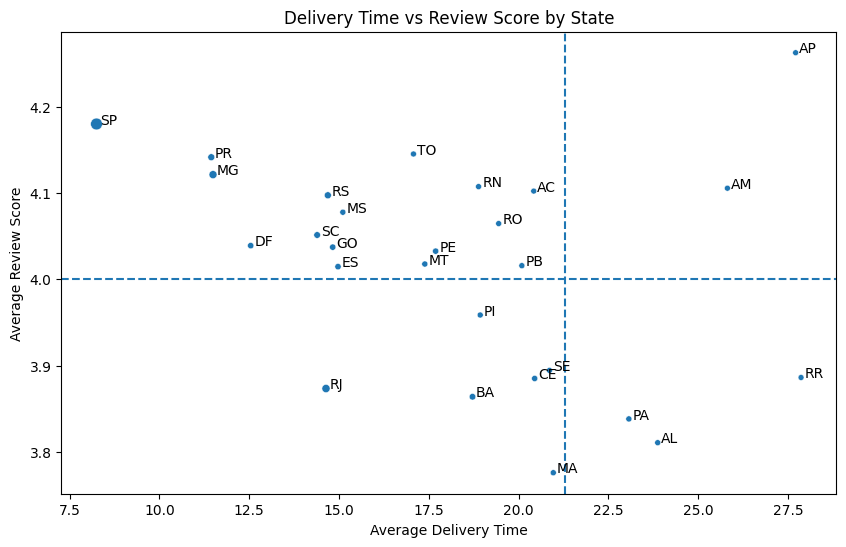

In [33]:
# 배송시간 X 리뷰의 주 확인 그래프에서 배송 느리나 리뷰 높은 곳을 확인하기 -> 확인 결과 AP, AM이 존재함

# 1-1 주(state)별 배송시간 vs 리뷰
state_summary = df.groupby('customer_state').agg({
    'delivery_time':'mean',
    'review_score':'mean',
    'order_id':'count'
}).reset_index()

# scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(data=state_summary,
                x='delivery_time',
                y='review_score',
                size='order_id',
                legend=False
)

# 주 이름 표시
for i,row in state_summary.iterrows():
    plt.text(row['delivery_time']+0.1,
             row['review_score'],
             row['customer_state'])
    
# review_score = 4 기준선
plt.axhline(y=4.0, linestyle='--')

# 전체 배송시간 평균 및 표준편차
mean_delivery = df['delivery_time'].mean()
std_delivery = df['delivery_time'].std()

# 평균선
# plt.axvline(mean_delivery, linestyle='-', label='Mean')

# +1σ선
plt.axvline(mean_delivery + std_delivery,
            linestyle='--',
            label='+1σ')

plt.title('Delivery Time vs Review Score by State')
plt.xlabel('Average Delivery Time')
plt.ylabel('Average Review Score')

plt.show()

In [34]:
# 1-2 AM / AP 특징 확인
df['is_amap'] = df['customer_state'].isin(['AM','AP'])

df_amap = df[df['is_amap']]

df_amap[['distance','price','freight_value','delivery_time']].describe()

# 데이터규모 : AM+AP주문건 : 243건 (전체데이터는 109000건으로 전체에 대한 비중이 0.22%) - 굉장히 작은 특이 집단임
# 거리 : 평균 2671km의 거리 (전체 평균은 595로 이 곳은 전체의 배송거리 보다 4.4배가 김)
# 배송시간 : 평균 26.47 일 (전체 평균 12일로 전체에 비해 배송시간이 2배이상 걸림)
# 가격 : 평균 145, 중간값 89로 - 고가상품이 평균을 끌어올림 
# 배송비 : 평균 33.6 (전체 평균 20보다 높은 수준)

,distance,price,freight_value,delivery_time
count,241.000000,241.000000,241.000000,241.000000
mean,2626.937552,144.933029,33.514564,26.443983
std,254.139569,214.658607,19.288596,18.955814
min,809.161298,8.500000,0.000000,4.000000
25%,2562.685100,47.490000,24.170000,19.000000
50%,2672.279190,89.900000,27.310000,25.000000
75%,2699.800737,149.900000,34.760000,31.000000
max,3343.265169,1688.000000,165.750000,187.000000


추가 가설: 거리가 배송시간에 영향을 미치고 배송시간이 리뷰에 영향을 주었다.

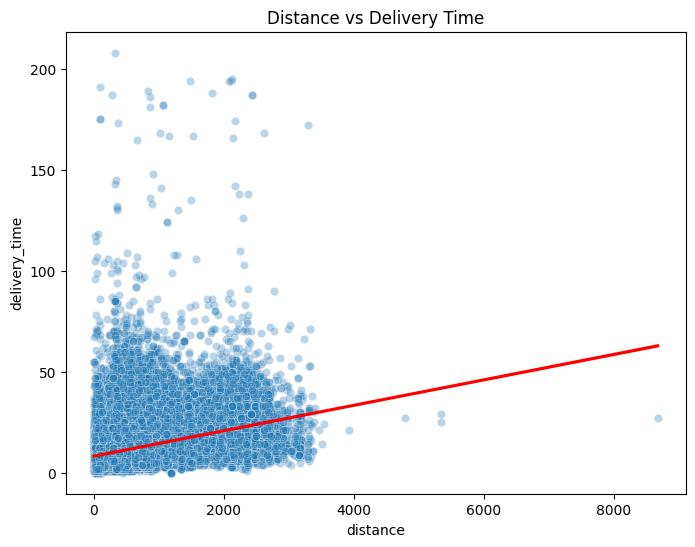

In [35]:
# 거리 vs 배송시간 관계

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="distance", y="delivery_time", alpha=0.3)

sns.regplot(data=df, x="distance", y="delivery_time", scatter=False, color="red")

plt.title("Distance vs Delivery Time")
plt.show()

In [36]:
# 거리 bin 분석

df["dist_bin"] = pd.cut(
    df["distance"],
    bins=[0,100,200,500,1000,2000,5000],
    labels=["0-100","100-200","200-500","500-1000","1000-2000","2000+"]
)

dist_summary = (
    df.groupby("dist_bin")
    .agg(
        avg_delivery=("delivery_time","mean"),
        avg_review=("review_score","mean"),
        n_orders=("order_id","count")
    )
)

dist_summary

,avg_delivery,avg_review,n_orders
dist_bin,,,
0-100,6.051808,4.222975,20074
100-200,8.272378,4.255429,7552
200-500,11.500394,4.064737,34231
500-1000,13.706632,4.036048,29100
1000-2000,17.381409,3.975655,10844
2000+,20.532842,3.927273,6105



3단계) 가설별 통계 분석

배송이 느린데, 리뷰가 왜 높은가?


가설1. 카테고리 때문일 것이다

카테고리 분포 비교

pd.crosstab(df['customer_state'],df['product_category_name_english'],normalize='index')

카이제곱 검정

from scipy.stats import chi2_contingency

chi2_contingency(pd.crosstab(df['customer_state'],df['product_category_name_english']))

*** 해석 : p < 0.05 → 카테고리 분포 차이 존재


가설2. 거리 때문일 것이다

거리 평균 비교

df.groupby('customer_state')['distance'].mean()

T-test

from scipy.stats import ttest_ind

ttest_ind(df[df.customer_state=='AM']['distance'],df[df.customer_state!='AM']['distance'])


가설3. 가격 영향

df.groupby('customer_state')['price'].mean()

검정

ttest_ind(df[df.customer_state=='AM']['price'],df[df.customer_state!='AM']['price'])


가설4 배송비 영향

df.groupby('customer_state')['freight_value'].mean()

검정

ttest_ind(df[df.customer_state=='AM']['freight_value'],df[df.customer_state!='AM']['freight_value'])


In [37]:
# 가설 1. 카테고리 영향
# 카테고리 확인
# AM/AP 지역 데이터
df_amap = df[df['is_amap']]

# AM/AP에서 많이 구매된 카테고리 Top10
df_amap['product_category_name_english'].value_counts().head(10)

product_category_name_english
health_beauty            30
computers_accessories    24
sports_leisure           20
telephony                19
watches_gifts            17
bed_bath_table           14
toys                     10
auto                      9
electronics               8
stationery                8
Name: count, dtype: int64

In [38]:
# 각 주 별 카테고리 분포 확인하기 (전체 패턴)
pd.crosstab(df['customer_state'],
            df['product_category_name_english'],
            normalize='index')

product_category_name_english,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,...,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
customer_state,,,,,,,,,,,,,,,,,,,,,
AC,0.000000,0.000000,0.000000,0.000000,0.000000,0.045455,0.034091,0.045455,0.022727,0.000000,...,0.000000,0.000000,0.011364,0.000000,0.102273,0.022727,0.000000,0.045455,0.034091,0.045455
AL,0.002364,0.002364,0.000000,0.000000,0.009456,0.049645,0.016548,0.042553,0.004728,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.075650,0.018913,0.000000,0.063830,0.028369,0.080378
AM,0.000000,0.006211,0.006211,0.000000,0.006211,0.037267,0.031056,0.049689,0.006211,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.080745,0.037267,0.006211,0.093168,0.043478,0.055901
AP,0.012500,0.000000,0.012500,0.000000,0.000000,0.037500,0.000000,0.075000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.087500,0.025000,0.000000,0.050000,0.037500,0.100000
BA,0.001393,0.001671,0.002786,0.000000,0.003900,0.042897,0.025905,0.067967,0.003621,0.000279,...,0.000000,0.001671,0.005014,0.000836,0.079387,0.020613,0.001671,0.066574,0.030919,0.062674
CE,0.004304,0.001435,0.000000,0.000000,0.003587,0.041607,0.022238,0.058106,0.005022,0.000000,...,0.000000,0.000000,0.005022,0.000000,0.064562,0.024390,0.000717,0.065997,0.045194,0.093974
DF,0.000000,0.001395,0.002791,0.000465,0.006977,0.049302,0.028837,0.091163,0.007442,0.000000,...,0.000465,0.000930,0.010698,0.000465,0.097209,0.019535,0.000000,0.036744,0.041395,0.059535
ES,0.000921,0.002302,0.000460,0.000000,0.006446,0.038674,0.028085,0.102210,0.005064,0.000000,...,0.000000,0.002762,0.001381,0.000000,0.079190,0.023941,0.001381,0.050645,0.043738,0.067219
GO,0.002277,0.003188,0.001366,0.000000,0.003188,0.034608,0.024590,0.107923,0.006375,0.000000,...,0.000000,0.002277,0.004554,0.000000,0.073770,0.021858,0.000455,0.054645,0.035519,0.064663


In [39]:
# 전체 주 비교 
# 카이제곱 독립성 검정 
# H0 : customer_state와 product_category는 서로 독립이다 -> 기각 : 주에 따라 구매 상품 카테고리 분포에는 통계적으로 유의한 차이가 존재한다 

chi2_contingency(
    pd.crosstab(df['customer_state'],
                df['product_category_name_english'])
)

Chi2ContingencyResult(statistic=np.float64(5197.774269240856), pvalue=np.float64(6.4470711465151e-310), dof=1872, expected_freq=array([[1.67954491e-01, 2.31548910e-01, 1.58986047e-01, ...,
        3.57107121e+00, 3.23842348e+00, 4.72963107e+00],
       [8.07326700e-01, 1.11301351e+00, 7.64217022e-01, ...,
        1.71654900e+01, 1.55665129e+01, 2.27344766e+01],
       [3.07280375e-01, 4.23629255e-01, 2.90872200e-01, ...,
        6.53343710e+00, 5.92484296e+00, 8.65307503e+00],
       ...,
       [7.06172290e-01, 9.73557915e-01, 6.68464061e-01, ...,
        1.50147312e+01, 1.36160987e+01, 1.98859488e+01],
       [8.72084607e+01, 1.20229140e+02, 8.25516983e+01, ...,
        1.85423815e+03, 1.68151459e+03, 2.45580719e+03],
       [5.78297849e-01, 7.97264995e-01, 5.47417866e-01, ...,
        1.22958475e+01, 1.11504808e+01, 1.62849797e+01]], shape=(27, 73)))

In [40]:
# AM/AP vs 다른 주 비교

# H0 : AM/AP 여부와 카테고리는 독립이다 -> p값으로 기각됨 : AM/AP 지역 소비패턴이 다른 지역과 다를 가능성이 큼

# AM/AP 여부 변수 생성 (True면 AM/AP False면 다른 주) + 상품 카테고리 교차표 생성
table = pd.crosstab(df['is_amap'], df['product_category_name_english'])

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(table); print("Chi2:", chi2, "| p-value:", p, "| dof:", dof)

Chi2: 167.78177616075314 | p-value: 1.2912174773652194e-09 | dof: 72


In [41]:
# AM/AP에서 많이 팔리는 카테고리 Top10

top_categories = (
    pd.crosstab(
        df.loc[df['is_amap'], 'customer_state'], 
        df.loc[df['is_amap'], 'product_category_name_english'],
        normalize='index'
    )
    .T
    .sort_values(by='AM', ascending=False)
    .head(10)
)

top_categories

customer_state,AM,AP
product_category_name_english,,
health_beauty,0.124224,0.1250
computers_accessories,0.099379,0.1000
telephony,0.093168,0.0500
sports_leisure,0.080745,0.0875
watches_gifts,0.055901,0.1000
bed_bath_table,0.049689,0.0750
toys,0.043478,0.0375
auto,0.037267,0.0375
stationery,0.037267,0.0250


In [42]:
# 가설 2. 거리 영향
df.groupby('customer_state')['distance'].mean()

customer_state
AC    2639.520957
AL    1834.843648
AM    2645.230268
AP    2590.123460
BA    1343.658698
CE    2188.042666
DF     829.847378
ES     804.307266
GO     774.936526
MA    2105.059260
MG     534.946745
MS     844.404809
MT    1351.273275
PA    2289.690472
PB    2101.319897
PE    1972.681542
PI    1958.853237
PR     486.725996
RJ     489.490946
RN    2098.982003
RO    2220.781054
RR    3244.525459
RS     867.728835
SC     572.366439
SE    1652.294988
SP     248.181661
TO    1483.161525
Name: distance, dtype: float64

In [43]:
# T-test
# H0 : AM 지역은 다른 지역보다 배송 거리가 같다. -> 기각 : 배송거리가 다르다.

ttest_ind(
    df[df.customer_state.isin(['AM','AP'])]['distance'],
    df[~df.customer_state.isin(['AM','AP'])]['distance'],
    equal_var=False
)

TtestResult(statistic=np.float64(123.61400297509887), pvalue=np.float64(3.48868360759593e-223), df=np.float64(245.63637239912273))

In [44]:
# 가설 3️. 가격 영향
df.groupby('customer_state')['price'].mean()

customer_state
AC    178.012159
AL    181.815414
AM    134.161180
AP    166.611375
BA    134.590618
CE    153.473623
DF    125.991005
ES    117.289540
GO    124.157523
MA    145.333613
MG    120.130613
MS    142.912321
MT    147.844951
PA    159.195906
PB    188.202809
PE    144.087564
PI    162.817760
PR    118.382116
RJ    124.210169
RN    157.952246
RO    169.944867
RR    154.806591
RS    119.058500
SC    122.946927
SE    149.758757
SP    109.254302
TO    157.052574
Name: price, dtype: float64

In [45]:
# t검정
# H0 : AM 지역과 타지역 상품 가격은 같다 -> 기각 실패 : AM 지역과 다른 지역간 상품 가격 차이는 통계적으로 유의하지 않았다.
ttest_ind(
    df[df.customer_state.isin(['AM','AP'])]['price'],
    df[~df.customer_state.isin(['AM','AP'])]['price'],
    equal_var=False
)

TtestResult(statistic=np.float64(1.8172299052457495), pvalue=np.float64(0.07042506344981471), df=np.float64(240.76127293194568))

In [46]:
# 가설 4. 배송비 영향 
df.groupby('customer_state')['freight_value'].mean()

customer_state
AC    40.426136
AL    35.773688
AM    33.133478
AP    34.281500
BA    26.447680
CE    32.805265
DF    21.144544
ES    21.980345
GO    22.782300
MA    38.538066
MG    20.643579
MS    23.343877
MT    28.170988
PA    35.407894
PB    43.147898
PE    32.771180
PI    39.263045
PR    20.551467
RJ    20.937950
RN    35.679648
RO    41.384411
RR    43.777500
RS    21.584841
SC    21.559813
SE    36.122811
SP    15.137268
TO    37.738086
Name: freight_value, dtype: float64

In [47]:
# t 검정
# H0 : AM 지역과 다른 지역의 평균 배송비(freight_value)는 같다. -> 기각 : AM 지역과 다른 지역의 평균 배송비가 유의미한 차이를 가지고 있다.
ttest_ind(
    df[df.customer_state.isin(['AM','AP'])]['freight_value'],
    df[~df.customer_state.isin(['AM','AP'])]['freight_value'],
    equal_var=False
)

TtestResult(statistic=np.float64(10.926994925367323), pvalue=np.float64(7.798047555005423e-23), df=np.float64(240.71126865652556))

In [48]:
# 가설 4-1. 배송비 비율 vs 리뷰

# 주문 단위로 중복 제거
df_order = df[['order_id', 'review_score', 'freight_ratio']].drop_duplicates(subset='order_id').copy()

# 구간 나누기
bins = [0, 0.1, 0.3, 0.5, 1, 2, 5, np.inf]
labels = ['0~0.1', '0.1~0.3', '0.3~0.5', '0.5~1', '1~2', '2~5', '5~']

df_order['freight_bin'] = pd.cut(
    df_order['freight_ratio'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 확인
print("주문 단위 행 수:", len(df_order))
print("리뷰 점수 수:", df_order['review_score'].count())
print("배송비 구간 수:", df_order['freight_bin'].value_counts().sum())
print("배송비 구간 NaN:", df_order['freight_bin'].isna().sum())

# 구간별 평균 리뷰 점수
ratio_review = (
    df_order.groupby('freight_bin', observed=False)['review_score']
      .mean()
      .reindex(labels)
)
display(ratio_review)

# 구간별 개수
ratio_count = (
    df_order['freight_bin']
    .value_counts()
    .reindex(labels)
)
display(ratio_count)

주문 단위 행 수: 94031
리뷰 점수 수: 94031
배송비 구간 수: 94031
배송비 구간 NaN: 0


freight_bin
0~0.1      4.211919
0.1~0.3    4.170989
0.3~0.5    4.121366
0.5~1      4.121789
1~2        4.036562
2~5        4.062112
5~         3.500000
Name: review_score, dtype: float64

freight_bin
0~0.1      14850
0.1~0.3    46155
0.3~0.5    18127
0.5~1      11914
1~2         2653
2~5          322
5~            10
Name: count, dtype: int64

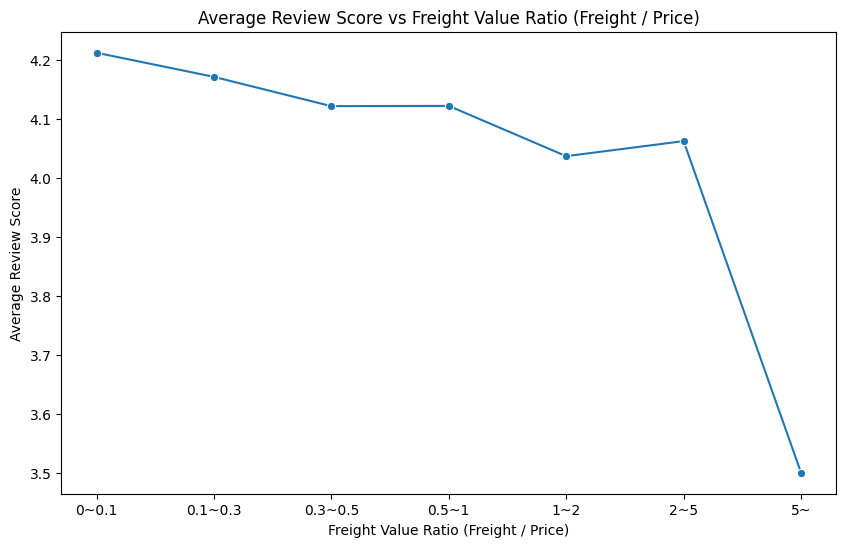

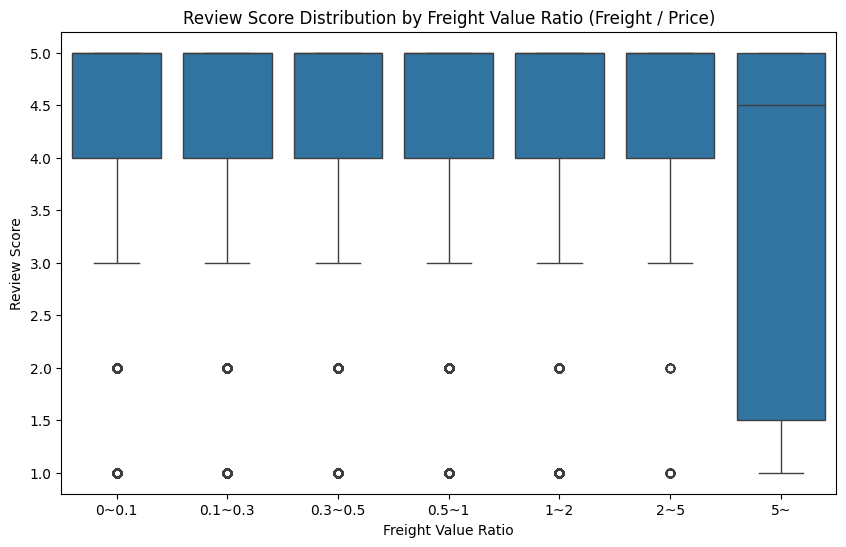

In [49]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=ratio_review.index.astype(str),
    y=ratio_review.values,
    marker='o'
)

plt.title("Average Review Score vs Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio (Freight / Price)")
plt.ylabel("Average Review Score")

plt.show()

###

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_order,
    x='freight_bin',
    y='review_score'
)

plt.title("Review Score Distribution by Freight Value Ratio (Freight / Price)")
plt.xlabel("Freight Value Ratio")
plt.ylabel("Review Score")

plt.show()



4단계) 상관분석
목적 : 리뷰에 영향 변수 확인
* Spearman correlation 사용 (리뷰점수는 ordinal)
df[['review_score','delivery_time','distance','price','freight_ratio']].corr(method='spearman')



In [50]:
# 상관 분석 (리뷰점수는 ordinal데이터 -> spearman 사용)
df[['review_score',
    'delivery_time',
    'distance',
    'price',
    'freight_ratio']].corr(method='spearman')

,review_score,delivery_time,distance,price,freight_ratio
review_score,1.000000,-0.221815,-0.065402,0.010122,-0.040217
delivery_time,-0.221815,1.000000,0.538131,0.115388,0.115331
distance,-0.065402,0.538131,1.000000,0.119704,0.209849
price,0.010122,0.115388,0.119704,1.000000,-0.815334
freight_ratio,-0.040217,0.115331,0.209849,-0.815334,1.000000


In [51]:
cols = ['review_score','delivery_time','distance','price','freight_ratio']

corr, pval = spearmanr(df[cols])

corr_df = pd.DataFrame(corr, index=cols, columns=cols)
pval_df = pd.DataFrame(pval, index=cols, columns=cols)

display(corr_df, pval_df)

,review_score,delivery_time,distance,price,freight_ratio
review_score,1.000000,-0.221815,-0.065402,0.010122,-0.040217
delivery_time,-0.221815,1.000000,0.538131,0.115388,0.115331
distance,-0.065402,0.538131,1.000000,0.119704,0.209849
price,0.010122,0.115388,0.119704,1.000000,-0.815334
freight_ratio,-0.040217,0.115331,0.209849,-0.815334,1.000000


,review_score,delivery_time,distance,price,freight_ratio
review_score,0.000000e+00,0.0,1.270688e-102,0.000883,6.921553e-40
delivery_time,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000e+00
distance,1.270688e-102,0.0,0.000000e+00,0.000000,0.000000e+00
price,8.825743e-04,0.0,0.000000e+00,0.000000,0.000000e+00
freight_ratio,6.921553e-40,0.0,0.000000e+00,0.000000,0.000000e+00


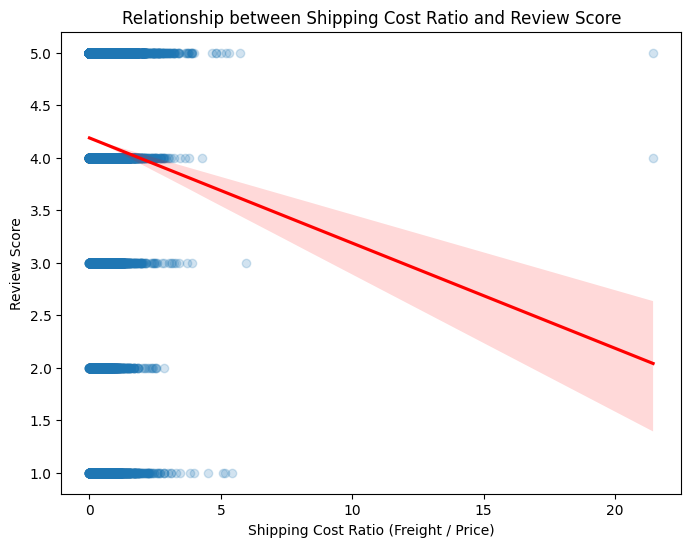

In [52]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_order,
    x='freight_ratio',
    y='review_score',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title("Relationship between Shipping Cost Ratio and Review Score")
plt.xlabel("Shipping Cost Ratio (Freight / Price)")
plt.ylabel("Review Score")

plt.show()

In [91]:
r, p = spearmanr(df["freight_ratio"], df["review_score"])

print("Spearman r:", r)
print("p-value:", p)

Spearman r: -0.04021711728388566
p-value: 6.9215525489091626e-40


### 추가 분석: 거리와 배송시간의 관계

앞선 상관분석에서는 거리가 리뷰 점수와 강한 직접적인 상관관계를 보이지 않았다.

하지만 이는 거리가 리뷰에 영향을 주지 않는다는 의미가 아니라,
거리가 배송시간을 증가시키고 배송시간이 다시 리뷰 점수에 영향을 미치는
간접적인 구조일 가능성을 의미할 수 있다.

따라서 거리와 배송시간 간의 관계를 추가적으로 확인한다.

In [53]:
r, p = spearmanr(df["distance"], df["delivery_time"])

print("Spearman r:", r)
print("p-value:", p)

Spearman r: 0.5381305043306424
p-value: 0.0


- 관계가 꽤 강하게 존재함.(거리와 배송시간은 중간 이상의 양의 상관관계를 보인다.)
- 거리와 배송시간 사이에는 통계적으로 유의미한 관계가 존재한다.
- 즉, 거리는 리뷰에 직접 영향을 주기보다는 배송시간을 통해 간접적으로 영향을 미칠 가능성이 있다.

5단계) 머신러닝 모델
목적 : 리뷰점수를 설명하는 핵심 변수 확인
타겟 : review_score
피처 :
delivery_time distance price freight_value freight_ratio product_category

5-1 모델 데이터 준비
X = df[['delivery_time','distance','price','freight_ratio']]
y = df['review_score']

5-2 train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

5-3 
모델 1 RandomForest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)

모델 2 XGBOOST

5-4 feature importance
pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)


- 본 분석에서는 order_item 단위 데이터를 사용하여 통계적 관계를 확인하였다.
- 다만 머신러닝 모델에서는 동일 주문에 대한 중복 샘플을 방지하기 위해 order 단위로 데이터를 집계하여 사용하였다.
- 근거: item level에서 분석의 관계 자체는 order level과 동일한 관계이다
-     그래서 aggregation을 해도 논리가 유지됨. 즉 정보 손실 없는 것임.

In [54]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'product_category_name_english', 'delivery_time',
       'freight_ratio', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng', 'distance', 'is_amap', 'dist_bi

In [55]:
# ML용 데이터 복사
df_ml = df.copy()

# 사용할 컬럼만 선택
use_cols = [
    "order_id",
    "review_score",
    "distance",
    "delivery_time",
    "price",
    "freight_ratio",
    "product_category_name_english"
]

df_ml = df_ml[use_cols].copy()

print(df_ml.shape)
df_ml.head()

(107934, 7)


,order_id,review_score,distance,delivery_time,price,freight_ratio,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,4.0,18.576135,8.0,29.99,0.290764,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,4.0,851.496245,13.0,118.70,0.191744,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,5.0,514.411377,9.0,159.90,0.120200,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,5.0,1822.228853,13.0,45.00,0.604444,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,5.0,29.676666,2.0,19.90,0.438191,stationery


In [56]:
print(df_ml.isnull().sum())

order_id                         0
review_score                     0
distance                         0
delivery_time                    0
price                            0
freight_ratio                    0
product_category_name_english    0
dtype: int64


In [57]:
# order item 단위 확인
print("rows:", len(df_ml))
print("unique orders:", df_ml["order_id"].nunique())
print("rows per order:", len(df_ml) / df_ml["order_id"].nunique())

order_counts = df_ml["order_id"].value_counts()
print(order_counts.describe())
print("orders with multiple rows:", (order_counts > 1).sum())

rows: 107934
unique orders: 94031
rows per order: 1.1478554944645916
count    94031.000000
mean         1.147855
std          0.550978
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         22.000000
Name: count, dtype: float64
orders with multiple rows: 9781


### order level로 집계
- distance: 첫 값
- delivery_time: 첫 값
- review_score: 첫 값
- price: 주문 내 평균
- freight_ratio: 주문 내 평균
- category: 주문 내 첫 카테고리

In [58]:
df_order = (
    df_ml.groupby("order_id")
    .agg(
        review_score=("review_score", "first"),
        distance=("distance", "first"),
        delivery_time=("delivery_time", "first"),
        price=("price", "mean"),
        freight_ratio=("freight_ratio", "mean"),
        category=("product_category_name_english", "first")
    )
    .reset_index()
)

print(df_order.shape)
df_order.head()

(94031, 7)


,order_id,review_score,distance,delivery_time,price,freight_ratio,category
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,301.505097,7.0,58.90,0.225637,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,4.0,585.564745,16.0,239.90,0.083076,pet_shop
2,000229ec398224ef6ca0657da4fc703e,5.0,312.343943,7.0,199.00,0.089799,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,4.0,293.168825,6.0,12.99,0.984604,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,646.164355,25.0,199.90,0.090745,garden_tools


In [59]:
# Define X and y
X = df_order[[
    "distance",
    "delivery_time",
    "price",
    "freight_ratio",
    "category"
]].copy()

y = df_order["review_score"].copy()

print(X.shape, y.shape)
X.head()

(94031, 5) (94031,)


,distance,delivery_time,price,freight_ratio,category
0,301.505097,7.0,58.90,0.225637,cool_stuff
1,585.564745,16.0,239.90,0.083076,pet_shop
2,312.343943,7.0,199.00,0.089799,furniture_decor
3,293.168825,6.0,12.99,0.984604,perfumery
4,646.164355,25.0,199.90,0.090745,garden_tools


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (75224, 5)
X_test : (18807, 5)
y_train: (75224,)
y_test : (18807,)


### Random Forest

In [61]:
# Build pipeline with target encoding
numeric_features = ["distance", "delivery_time", "price", "freight_ratio"]
categorical_features = ["category"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat_te", ce.TargetEncoder(cols=categorical_features), categorical_features)
    ],
    remainder="drop"
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [62]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

In [63]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [64]:
print("Best Params:")
print(grid_search.best_params_)

print("Best CV MAE:", -grid_search.best_score_)

Best Params:
{'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV MAE: 0.9041648137772551


In [65]:
best_rf_model = grid_search.best_estimator_

y_pred = best_rf_model.predict(X_test)

In [66]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R2  :", r2)

Test MAE : 0.904553327161632
Test RMSE: 1.1779763722986731
Test R2  : 0.1450774482219681


### XGBoost

In [67]:
numeric_features = ["distance", "delivery_time", "price", "freight_ratio"]
categorical_features = ["category"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat_te", ce.TargetEncoder(cols=categorical_features), categorical_features)
    ],
    remainder="drop"
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

In [68]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [69]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [70]:
print("Best Params:")
print(grid_search.best_params_)

print("\nBest CV Score (negative MAE):")
print(grid_search.best_score_)

print("Best CV MAE:", -grid_search.best_score_)

Best Params:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best CV Score (negative MAE):
-0.9003789967492132
Best CV MAE: 0.9003789967492132


In [71]:
best_xgb_model = grid_search.best_estimator_

y_pred = best_xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R2  :", r2)

Test MAE : 0.9015129418085844
Test RMSE: 1.1781683209917175
Test R2  : 0.14479880997369787



6단계) Feature Importance 해석

: 거리 영향이 가장 큼

### Random Forest Feature importance & SHAP

In [72]:
feature_names = numeric_features + ["category_te"]

importances = best_rf_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

importance_df

,feature,importance
1,delivery_time,0.698612
0,distance,0.117236
3,freight_ratio,0.064799
4,category_te,0.060079
2,price,0.059274


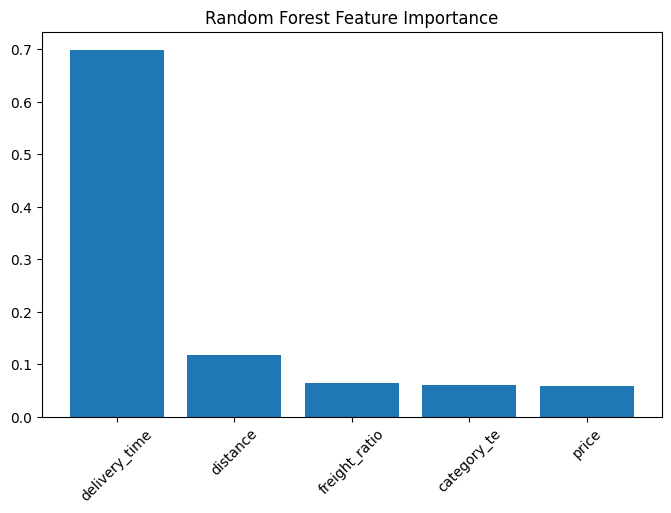

In [73]:
plt.figure(figsize=(8, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [74]:
preprocessor_fitted = best_rf_model.named_steps["preprocessor"]
rf_fitted = best_rf_model.named_steps["model"]
X_test_transformed = preprocessor_fitted.transform(X_test)
feature_names = numeric_features + ["category_te"]

In [75]:
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_transformed_df.head()

,distance,delivery_time,price,freight_ratio,category_te
11177,32.985951,5.0,32.5,0.239385,4.195258
49960,383.244686,38.0,139.9,0.299929,4.231952
87802,428.269787,33.0,115.0,0.185217,4.233321
5038,477.518804,10.0,110.0,0.000000,4.120833
21842,422.448485,17.0,77.0,0.198571,4.128594


In [76]:
explainer = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_test_transformed_df)

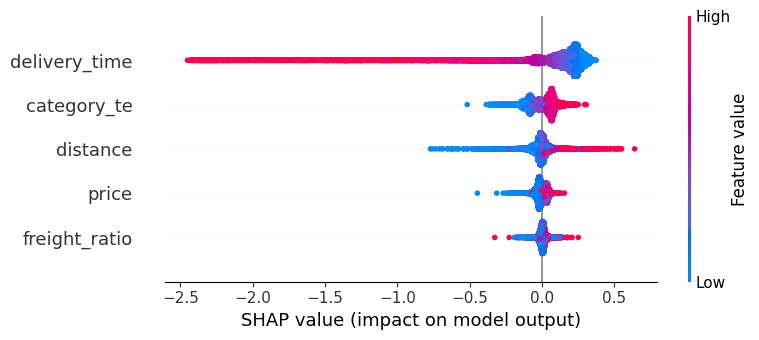

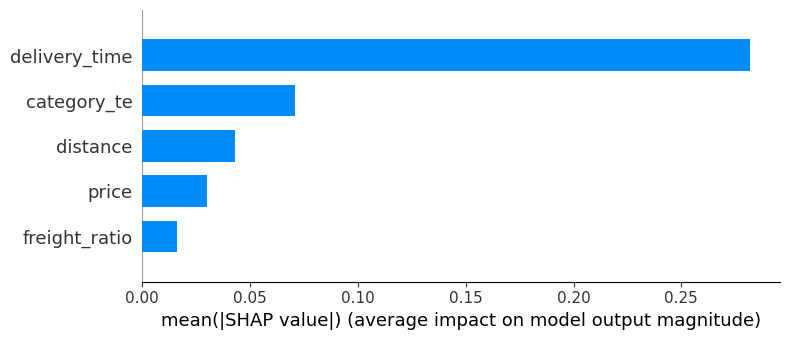

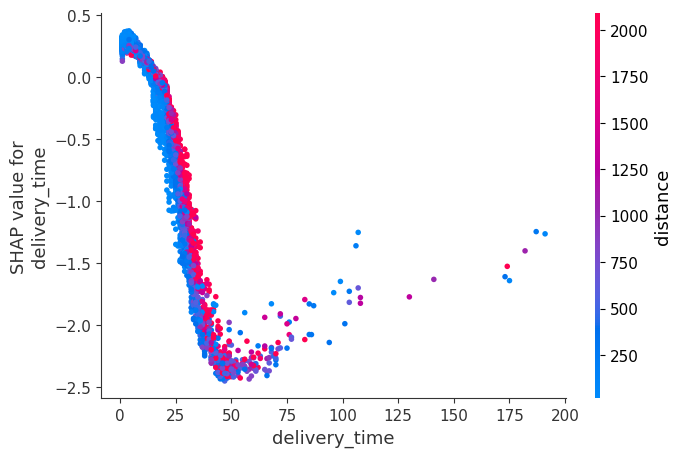

In [77]:
# summary plot
shap.summary_plot(shap_values, X_test_transformed_df)

# bar plot
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

# dependence plots
shap.dependence_plot("delivery_time", shap_values, X_test_transformed_df)

### XGBOOST Feature importance & SHAP

In [78]:
feature_names = numeric_features + ["category_te"]

importances = best_xgb_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

importance_df

,feature,importance
1,delivery_time,0.765347
0,distance,0.103192
4,category_te,0.072324
2,price,0.031572
3,freight_ratio,0.027565


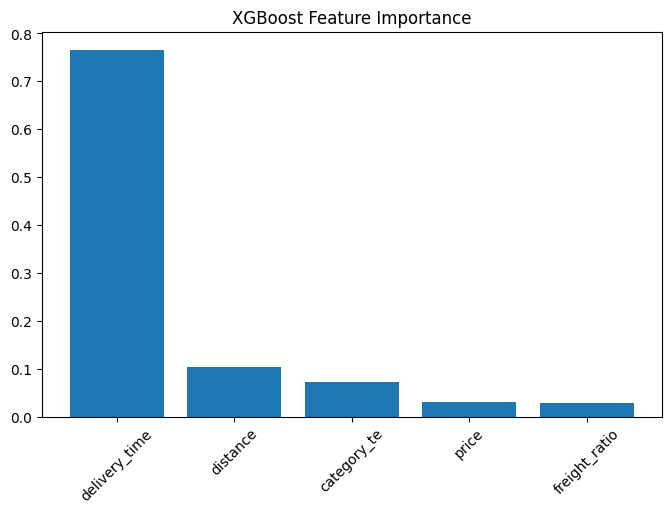

In [79]:
plt.figure(figsize=(8, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [80]:
preprocessor_fitted = best_xgb_model.named_steps["preprocessor"]
xgb_fitted = best_xgb_model.named_steps["model"]

X_test_transformed = preprocessor_fitted.transform(X_test)

feature_names = ["distance", "delivery_time", "price", "freight_ratio", "category_te"]

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_transformed_df.head()

,distance,delivery_time,price,freight_ratio,category_te
11177,32.985951,5.0,32.5,0.239385,4.195258
49960,383.244686,38.0,139.9,0.299929,4.231952
87802,428.269787,33.0,115.0,0.185217,4.233321
5038,477.518804,10.0,110.0,0.000000,4.120833
21842,422.448485,17.0,77.0,0.198571,4.128594


In [81]:
booster = xgb_fitted.get_booster()

dm_test = DMatrix(
    X_test_transformed_df,
    feature_names=feature_names
)

shap_contrib = booster.predict(dm_test, pred_contribs=True)

In [82]:
shap_values = shap_contrib[:, :-1]
base_values = shap_contrib[:, -1]

print("shap_values shape:", shap_values.shape)
print("base_values shape:", base_values.shape)

shap_values shape: (18807, 5)
base_values shape: (18807,)


In [83]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance

,feature,mean_abs_shap
1,delivery_time,0.312500
2,price,0.071456
0,distance,0.070948
4,category_te,0.067694
3,freight_ratio,0.049413


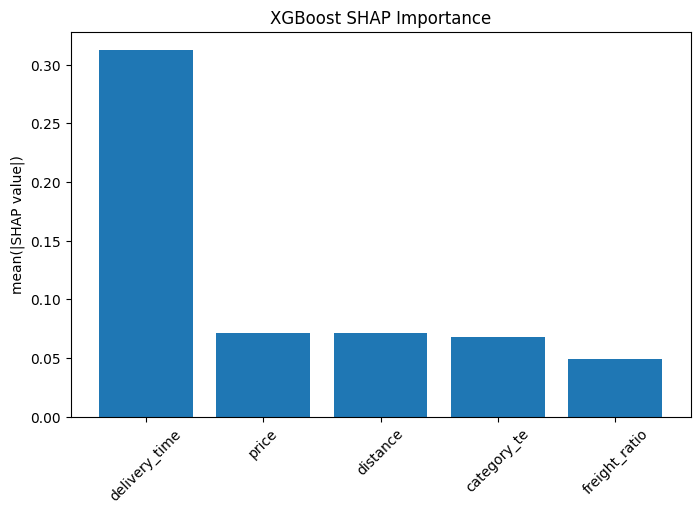

In [84]:
plt.figure(figsize=(8, 5))
plt.bar(shap_importance["feature"], shap_importance["mean_abs_shap"])
plt.title("XGBoost SHAP Importance")
plt.xticks(rotation=45)
plt.ylabel("mean(|SHAP value|)")
plt.show()

In [85]:
exp = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_test_transformed_df.values,
    feature_names=feature_names
)

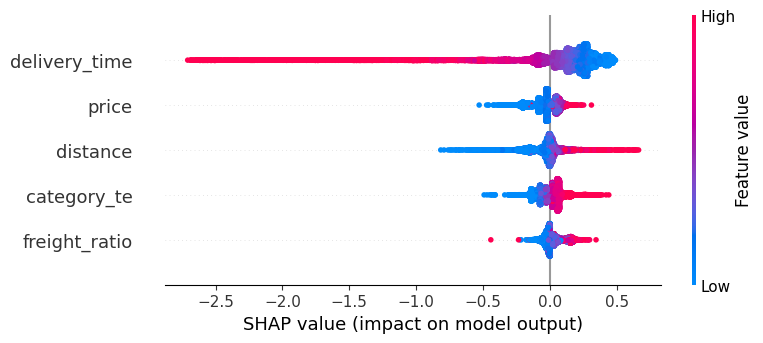

In [86]:
shap.plots.beeswarm(exp)

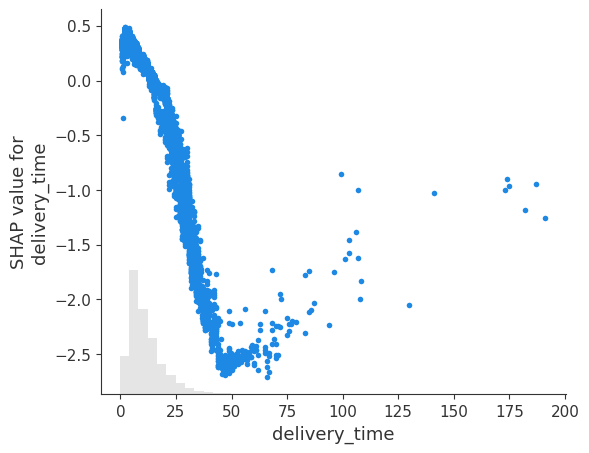

In [87]:
shap.plots.scatter(exp[:, "delivery_time"])

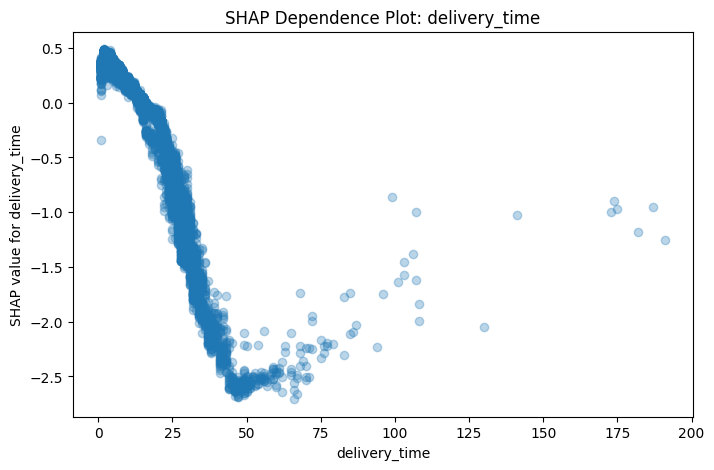

In [88]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test_transformed_df["delivery_time"],
    shap_values[:, feature_names.index("delivery_time")],
    alpha=0.3
)
plt.xlabel("delivery_time")
plt.ylabel("SHAP value for delivery_time")
plt.title("SHAP Dependence Plot: delivery_time")
plt.show()

### 모델의 Test R2  : 0.145 모델이 데이터를 제대로 설명 못하는데 안좋은 모델이 아닌가?
1. baseline과 비교
※ baseline이란: "아무것도 학습하지 않아도 낼 수 있는 최소한의 성능"

In [89]:
dummy = DummyRegressor(strategy="mean")
scores = -cross_val_score(dummy, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)

scores.mean()

np.float64(1.0010016378835254)

- Dummy MAE = 1.001
- 위의 모델이 baseline 모델에 비해서 평균에러를 0.1 리뷰 스코어 만큼 줄여준다.
- 단순 평균 예측 모델 대비 약 10%의 오류 감소가 나타났기 때문에, 모델은 실제로 데이터에서 의미 있는 패턴을 학습하고 있다고 볼 수 있습니다.

2. Review score의 구조적 문제
리뷰 점수가 매우 한쪽으로 치우쳐 있기 때문에 설명 가능한 분산 자체가 작으며, 이로 인해 R²가 낮게 나타나는 것이 자연스럽다.

In [90]:
df["review_score"].value_counts(normalize=True).sort_index()

review_score
1.0    0.113727
2.0    0.033632
3.0    0.084264
4.0    0.192544
5.0    0.575833
Name: proportion, dtype: float64

3. 설명 변수 한계(데이터의 한계)
리뷰는 실제로 Olist데이터에 들어있는 feature들 말고도 다음에 영향을 받습니다.
- product quality
- expectation mismatch
- seller communication
- defective item
- packaging
- customer personality

#### 다만, R²가 낮다는 것은 우리가 가진 변수들이 전체 현상을 모두 설명하지 못한다는 뜻이지, 그 변수들이 의미가 없다는 뜻은 아니다.
Baseline 대비 개선은 실제 feature target 사이에 실제 정보가 존재한다는 의미이기에, feature importance를 보는 것은 의미가 있다.


* 최종 인사이트 구조

- 모델의 feature importance 결과에 따르면 delivery_time의 중요도는 약 0.70으로, 다른 변수들보다 압도적으로 높은 값을 보였다.
- 이는 고객 리뷰 점수가 물리적 거리(distance) 자체보다는 실제 배송 경험, 즉 배송이 얼마나 빠르게 이루어졌는지에 더 크게 영향을 받는다는 점을 시사한다.
- 실제로 distance의 중요도는 약 0.12 수준으로 delivery_time에 비해 훨씬 낮게 나타났는데, 
- 이는 거리가 멀더라도 배송이 예상보다 빠르게 이루어지면 고객 만족도가 크게 저하되지 않을 수 있음을 의미한다.
- 또한 freight_ratio, price, category와 같은 제품 관련 변수들은 중요도가 약 0.06 수준으로 비교적 낮게 나타났다. 이는 고객 리뷰 점수가 제품 가격이나 배송비 비율보다는 배송 과정에서의 서비스 경험에 더 민감하게 반응한다는 해석을 가능하게 한다.